In [1]:
!pip install -q kaggle tensorflow matplotlib scikit-learn

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"meetarora05","key":"c183facb7420881e98c7c904559dfb87"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d mahendarbyra/behsof-dataset -p /content
!unzip -q "/content/behsof-dataset.zip" -d "/content/behsof"

Dataset URL: https://www.kaggle.com/datasets/mahendarbyra/behsof-dataset
License(s): other
100% 319M/319M [00:03<00:00, 96.8MB/s]



In [5]:
import os

SOURCE_DIR = "/content/behsof/BEHSOF"
SPLIT_DIR = "/content/behsof_split"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 10

In [6]:
import shutil
from sklearn.model_selection import train_test_split

classes = [d for d in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, d))]

for split in ["train", "val", "test"]:
    for c in classes:
        os.makedirs(os.path.join(SPLIT_DIR, split, c), exist_ok=True)

for c in classes:
    files = [
        os.path.join(SOURCE_DIR, c, f)
        for f in os.listdir(os.path.join(SOURCE_DIR, c))
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
    ]

    train_files, temp_files = train_test_split(
        files,
        test_size=0.30,
        random_state=SEED,
        shuffle=True
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=SEED,
        shuffle=True
    )

    for f in train_files:
        shutil.copy2(f, os.path.join(SPLIT_DIR, "train", c, os.path.basename(f)))

    for f in val_files:
        shutil.copy2(f, os.path.join(SPLIT_DIR, "val", c, os.path.basename(f)))

    for f in test_files:
        shutil.copy2(f, os.path.join(SPLIT_DIR, "test", c, os.path.basename(f)))

print("Split complete.")

Split complete.


In [7]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for c in classes:
        folder = os.path.join(SPLIT_DIR, split, c)
        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
        ])
        print(c, ":", count)


TRAIN
Non-NAFLD : 106
NAFLD : 1061

VAL
Non-NAFLD : 23
NAFLD : 228

TEST
Non-NAFLD : 23
NAFLD : 228


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 1167 files belonging to 2 classes.
Found 251 files belonging to 2 classes.
Found 251 files belonging to 2 classes.
Classes: ['NAFLD', 'Non-NAFLD']


In [9]:
train_ds = train_ds.prefetch(1)
val_ds = val_ds.prefetch(1)
test_ds = test_ds.prefetch(1)

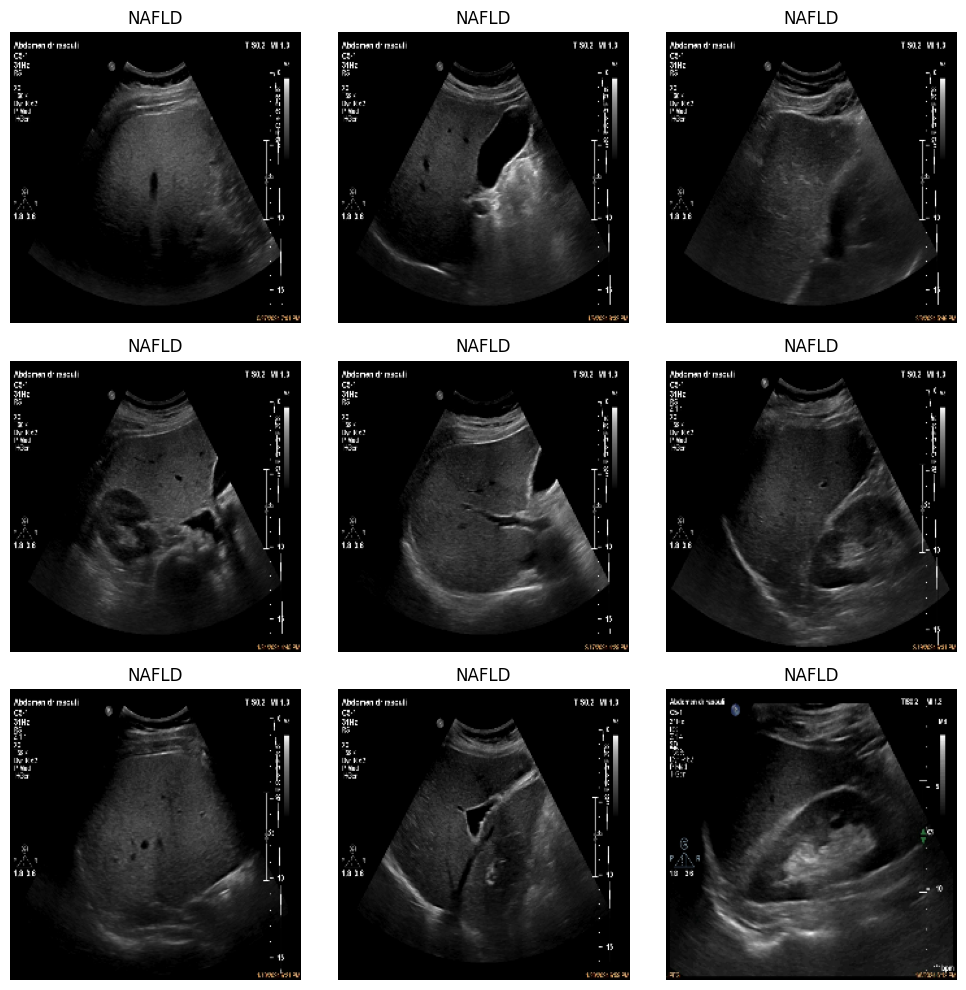

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
class_counts = {}
for _, labels in train_ds.unbatch():
    label = int(labels.numpy())
    class_counts[label] = class_counts.get(label, 0) + 1

print("Class counts:", class_counts)

total = sum(class_counts.values())
class_weight = {
    cls: total / (len(class_counts) * count)
    for cls, count in class_counts.items()
}

print("Class weights:", class_weight)

Class counts: {0: 1061, 1: 106}
Class weights: {0: 0.5499528746465598, 1: 5.504716981132075}


In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.20),
])

base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.5
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "fatty_liver_checkpoint_stage1.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

In [15]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks_stage1,
    class_weight=class_weight
)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.7095 - loss: 0.6795 - val_accuracy: 0.6614 - val_loss: 0.6417 - learning_rate: 1.0000e-04
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.7704 - loss: 0.5341 - val_accuracy: 0.7450 - val_loss: 0.5620 - learning_rate: 1.0000e-04
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8218 - loss: 0.4546 - val_accuracy: 0.6773 - val_loss: 0.6311 - learning_rate: 1.0000e-04
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8218 - loss: 0.4009 - val_accuracy: 0.7131 - val_loss: 0.5959 - learning_rate: 1.0000e-04
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8466 - loss: 0.4018 - val_accuracy: 0.7371 - val_loss: 0.5581 - learning_rate: 5.0000e-05
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8638 - loss: 0.3834 - val_accuracy: 0.7450 - val_loss: 0.5709 - learning_rate: 5.0000e-05
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.8526 - loss

In [16]:
print("Stage 1 epochs actually run:", len(history_stage1.history["loss"]))
print(history_stage1.history.keys())

Stage 1 epochs actually run: 19
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


In [17]:
base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.5
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "fatty_liver_checkpoint_stage2.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

In [19]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_stage2,
    class_weight=class_weight
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9023 - loss: 0.5086 - val_accuracy: 0.7530 - val_loss: 0.5994 - learning_rate: 1.0000e-05
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.8715 - loss: 0.4191 - val_accuracy: 0.7769 - val_loss: 0.5777 - learning_rate: 1.0000e-05
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.8809 - loss: 0.3492 - val_accuracy: 0.8048 - val_loss: 0.5211 - learning_rate: 1.0000e-05
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.8646 - loss: 0.3756 - val_accuracy: 0.8048 - val_loss: 0.5161 - learning_rate: 1.0000e-05
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.8698 - loss: 0.3290 - val_accuracy: 0.7888 - val_loss: 0.5309 - learning_rate: 1.0000e-05
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8757 - loss: 0.3344 - val_accuracy: 0.7530 - val_loss: 0.5619 - learning_rate: 1.0000e-05
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.8749 

In [20]:
print("Stage 2 epochs actually run:", len(history_stage2.history["loss"]))
print(history_stage2.history.keys())

Stage 2 epochs actually run: 7
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


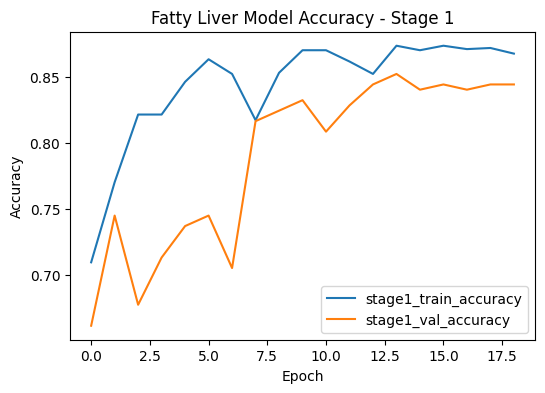

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(history_stage1.history["accuracy"], label="stage1_train_accuracy")
plt.plot(history_stage1.history["val_accuracy"], label="stage1_val_accuracy")
plt.title("Fatty Liver Model Accuracy - Stage 1")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

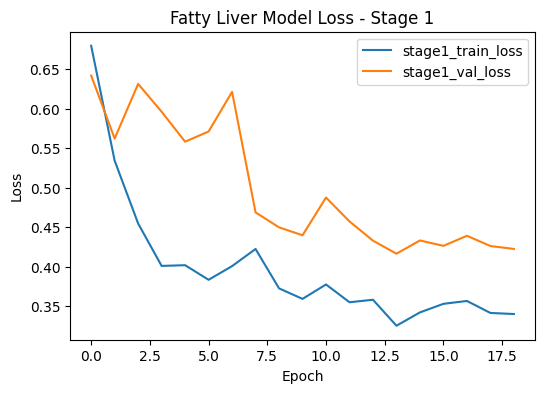

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(history_stage1.history["loss"], label="stage1_train_loss")
plt.plot(history_stage1.history["val_loss"], label="stage1_val_loss")
plt.title("Fatty Liver Model Loss - Stage 1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

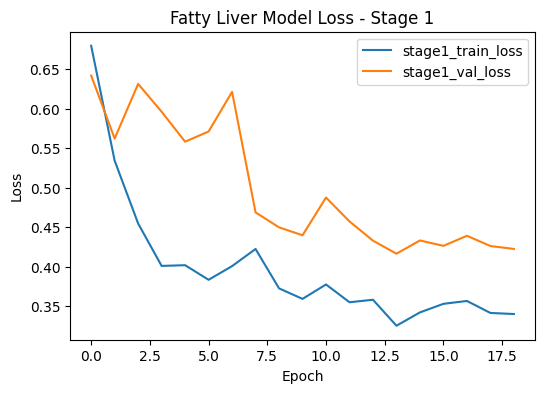

In [23]:
plt.figure(figsize=(6, 4))
plt.plot(history_stage1.history["loss"], label="stage1_train_loss")
plt.plot(history_stage1.history["val_loss"], label="stage1_val_loss")
plt.title("Fatty Liver Model Loss - Stage 1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

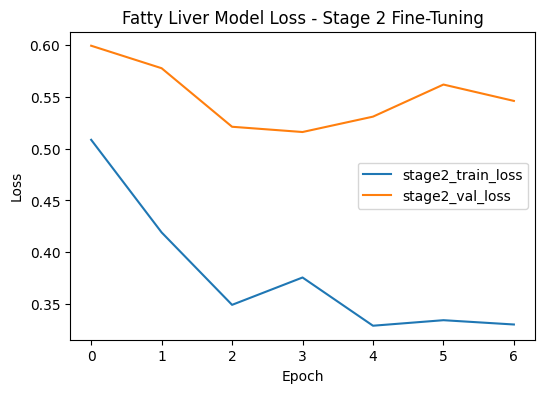

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(history_stage2.history["loss"], label="stage2_train_loss")
plt.plot(history_stage2.history["val_loss"], label="stage2_val_loss")
plt.title("Fatty Liver Model Loss - Stage 2 Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [25]:
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Validation Accuracy: 0.804780900478363
Test Accuracy: 0.7928286790847778


In [26]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1 Score:", f1_score(y_true, y_pred, average="macro"))

              precision    recall  f1-score   support

       NAFLD       0.99      0.78      0.87       228
   Non-NAFLD       0.30      0.91      0.45        23

    accuracy                           0.79       251
   macro avg       0.64      0.85      0.66       251
weighted avg       0.93      0.79      0.83       251

Confusion Matrix:
 [[178  50]
 [  2  21]]
Balanced Accuracy: 0.8468726163234173
Macro F1 Score: 0.6596787651230704


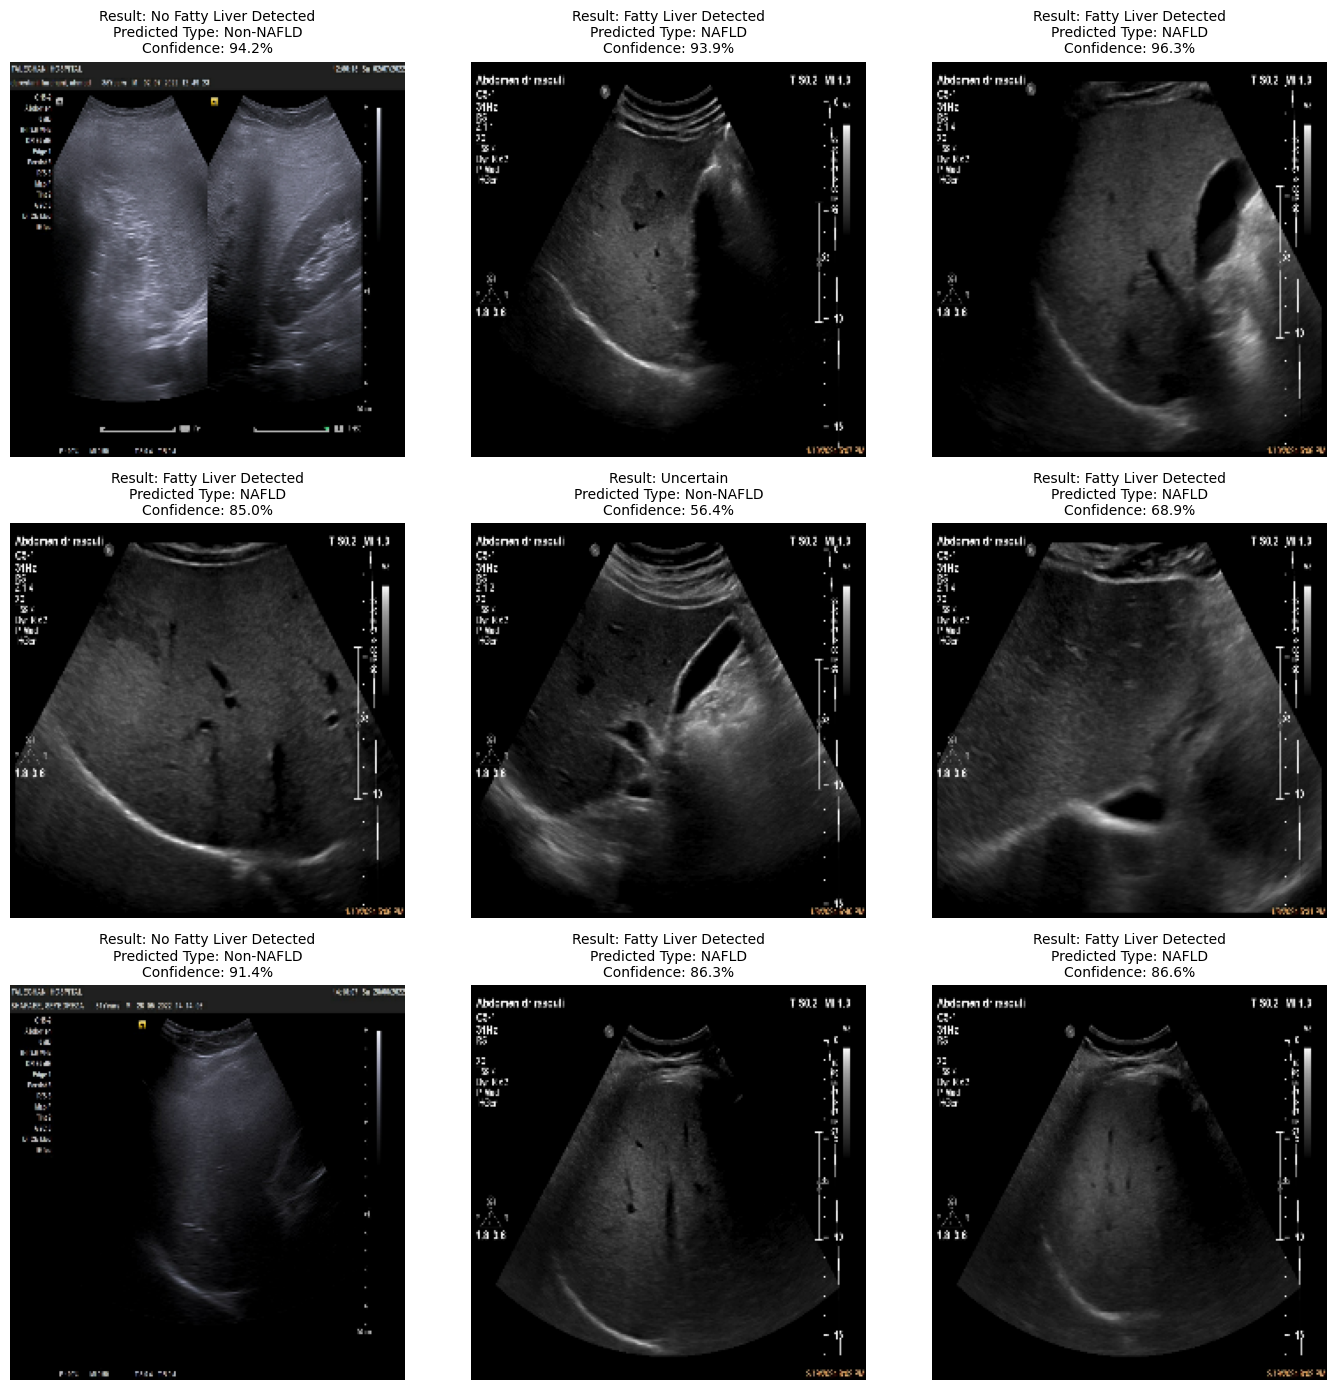

In [27]:
plt.figure(figsize=(14, 14))

for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)

    nafld_idx = class_names.index("NAFLD")
    non_nafld_idx = class_names.index("Non-NAFLD")

    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        nafld_prob = float(preds[i][nafld_idx])
        non_nafld_prob = float(preds[i][non_nafld_idx])
        margin = abs(nafld_prob - non_nafld_prob)

        if margin < 0.15:
            result = "Uncertain"
            pred_name = class_names[int(np.argmax(preds[i]))]
            confidence = max(nafld_prob, non_nafld_prob) * 100
        elif nafld_prob > non_nafld_prob:
            result = "Fatty Liver Detected"
            pred_name = "NAFLD"
            confidence = nafld_prob * 100
        else:
            result = "No Fatty Liver Detected"
            pred_name = "Non-NAFLD"
            confidence = non_nafld_prob * 100

        plt.title(
            f"Result: {result}\nPredicted Type: {pred_name}\nConfidence: {confidence:.1f}%",
            fontsize=10
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0]

nafld_idx = class_names.index("NAFLD")
non_nafld_idx = class_names.index("Non-NAFLD")

nafld_prob = float(prediction[nafld_idx])
non_nafld_prob = float(prediction[non_nafld_idx])
margin = abs(nafld_prob - non_nafld_prob)

if margin < 0.15:
    result = "Uncertain"
    pred_class_name = class_names[int(np.argmax(prediction))]
    confidence = max(nafld_prob, non_nafld_prob) * 100
elif nafld_prob > non_nafld_prob:
    result = "Fatty Liver Detected"
    pred_class_name = "NAFLD"
    confidence = nafld_prob * 100
else:
    result = "No Fatty Liver Detected"
    pred_class_name = "Non-NAFLD"
    confidence = non_nafld_prob * 100

plt.figure(figsize=(6, 6))
plt.imshow(image.load_img(img_path))
plt.title(
    f"Result: {result}\nPredicted Type: {pred_class_name}\nConfidence: {confidence:.1f}%",
    fontsize=12
)
plt.axis("off")
plt.show()

print(f"Result: {result}")
print(f"Predicted Type: {pred_class_name}")
print(f"Confidence: {confidence:.1f}%")
print("Raw Probabilities:", prediction)
print("Decision Margin:", round(margin, 4))

In [ ]:
model.save("fatty_liver_model_224_finetuned.keras")
print("Model saved successfully")